# Analysis for N.Haket's PhD Thesis Chapter 7


This notebook provides a comprehensive analysis of the interpretive strategies elicited by 10 target words across 1,200 responses. It begins by summarizing the overall distribution of the four response categories (PAR, SIT, INF, EVA), visualizing both aggregated and word-level percentages.

The analysis then tests whether words differ significantly in the types of responses they elicit using chi-square tests, Cramér’s V effect sizes, and per-category goodness-of-fit tests, highlighting which words contribute most to observed differences, using scaled counts to counteract imbalanced results.

 Additionally, the notebook includes a sensitivity analysis excluding the word “Computer” and explores variability at the individual dialogue level, presenting detailed plots and tables to support interpretation of patterns across words and discourses.

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency, chi2
import numpy as np

# Load the CSV file into a DataFrame
df = pd.read_csv('/content/Final Overview_aggregate.csv')


# Display the DataFrame
df.head(10)  # Displaying the first few rows of the DataFrame

,Word,PAR,SIT,INF,EVA,Total
0,Computer,46,23,26,25,120
1,Education,51,19,37,13,120
2,Energy,55,21,32,7,115
3,Freedom,56,17,36,11,120
4,Friend,74,17,18,11,120
5,Planet,57,32,24,7,120
6,System,64,17,31,8,120
7,Theory,53,18,33,16,120
8,Truth,70,13,25,12,120
9,Water,75,16,24,5,120


##Overall category distribution

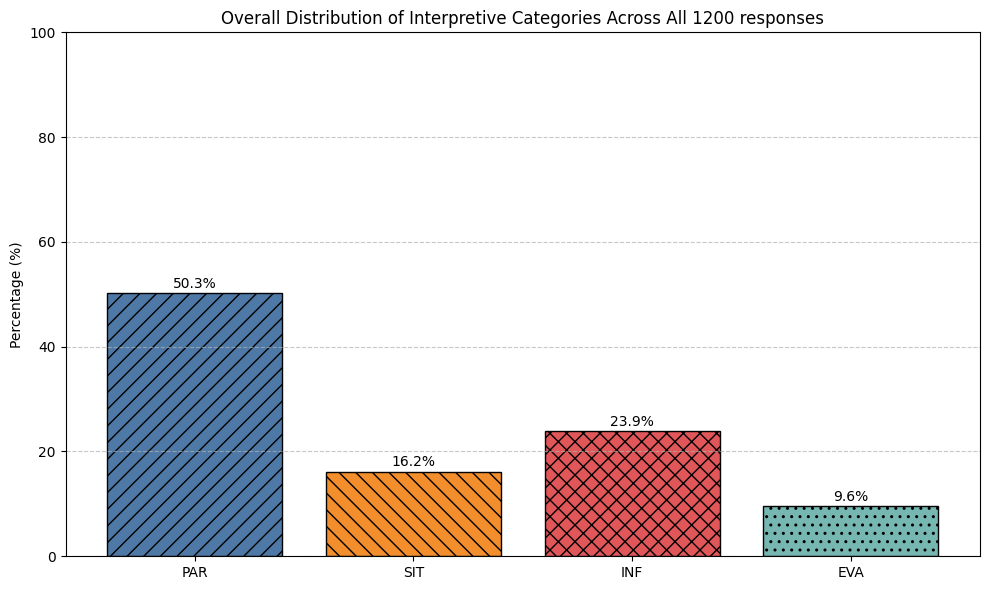

In [25]:
# Load the CSV file
df = pd.read_csv('/content/Final Overview_aggregate.csv')

# Sum each category across all words
category_totals = df[["PAR", "SIT", "INF", "EVA"]].sum()

# Convert to percentage of total if desired
category_percent = (category_totals / category_totals.sum()) * 100

# Prepare plotting data
categories = category_totals.index
values = category_percent.values

# Define appearance settings (matching your previous plot)
hatches = ["//", "\\\\", "xx", ".."]
colors = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2"]  # Colorblind-friendly palette

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars
bars = ax.bar(categories, values, color=colors, edgecolor="black")

# Apply hatches
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

# Labeling
ax.set_ylabel("Percentage (%)")
ax.set_title("Overall Distribution of Interpretive Categories Across All 1200 responses")
ax.set_ylim(0, 100)

# Add value labels above bars
for i, v in enumerate(values):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=10)

# Grid, layout, and display
ax.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


##Statistical Significance of Lexical Item on Interpretive Strategy


In [26]:
# Load the CSV file
df = pd.read_csv('/content/Final Overview_aggregate.csv')

# Categories and standard total
categories = ['PAR', 'SIT', 'INF', 'EVA']
standard_total = 120  # standard responses per word

# Convert raw counts to percentages per word
df_percent = df.copy()
df_percent['Total'] = df[categories].sum(axis=1)  # compute totals if needed
for cat in categories:
    df_percent[cat] = df_percent[cat] / df_percent['Total'] * 100

# Scale percentages to common total for chi-square
scaled_counts = (df_percent[categories] / 100 * standard_total).round().astype(int)

# -------------------------------
# Method 1: Global Chi-square Test
# -------------------------------
print("METHOD 1: CHI-SQUARE TEST WITH EFFECT SIZE FOCUS")
print("-" * 60)

contingency_table = scaled_counts.values

# Perform chi-square test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

# Calculate effect size (Cramér's V)
n_total = contingency_table.sum()
cramers_v = np.sqrt(chi2_stat / (n_total * (min(contingency_table.shape) - 1)))

print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")
print(f"Cramér's V (effect size): {cramers_v:.4f}")
print(f"Effect size interpretation: {effect_interpretation}")
print(f"Variance explained: {cramers_v**2:.1%}")
print(f"\n" + "="*60)

# -------------------------------
# Method 2: Separate Tests per Category
# -------------------------------
print("METHOD 2: SEPARATE TESTS FOR EACH CATEGORY")
print("-" * 60)

category_results = {}

for category in categories:
    # Test if this category varies significantly across words
    observed = scaled_counts[category].values
    expected_equal = np.full(len(observed), np.mean(observed))

    # Chi-square goodness of fit
    chi2_cat, p_cat = stats.chisquare(observed, expected_equal)

    # Effect size: coefficient of variation
    cv = np.std(observed) / np.mean(observed)

    category_results[category] = {
        'chi2': chi2_cat,
        'p_value': p_cat,
        'coefficient_variation': cv,
        'mean': np.mean(observed),
        'std': np.std(observed),
        'range': np.max(observed) - np.min(observed)
    }

    print(f"\n{category}:")
    print(f"  Chi-square: {chi2_cat:.4f}, p-value: {p_cat:.4f}")
    print(f"  Coefficient of variation: {cv:.4f}")
    print(f"  Mean ± SD: {np.mean(observed):.1f} ± {np.std(observed):.1f}")
    print(f"  Range: {np.min(observed)} - {np.max(observed)}")

print(f"\n" + "="*60)



METHOD 1: CHI-SQUARE TEST WITH EFFECT SIZE FOCUS
------------------------------------------------------------
Chi-square statistic: 65.8501
P-value: 0.000043
Degrees of freedom: 27
Cramér's V (effect size): 0.1353
Effect size interpretation: small (0.1-0.3)
Variance explained: 1.8%

METHOD 2: SEPARATE TESTS FOR EACH CATEGORY
------------------------------------------------------------

PAR:
  Chi-square: 14.8607, p-value: 0.0948
  Coefficient of variation: 0.1570
  Mean ± SD: 60.3 ± 9.5
  Range: 46 - 75

SIT:
  Chi-square: 12.9072, p-value: 0.1668
  Coefficient of variation: 0.2579
  Mean ± SD: 19.4 ± 5.0
  Range: 13 - 32

INF:
  Chi-square: 11.9895, p-value: 0.2139
  Coefficient of variation: 0.2044
  Mean ± SD: 28.7 ± 5.9
  Range: 18 - 37

EVA:
  Chi-square: 26.1304, p-value: 0.0019
  Coefficient of variation: 0.4767
  Mean ± SD: 11.5 ± 5.5
  Range: 5 - 25



In [27]:
# Get EVA data
eva_observed = df['EVA'].values
eva_mean = np.mean(eva_observed)
eva_std = np.std(eva_observed)
eva_expected = eva_mean

# Calculate contribution to chi-square for each word
eva_detailed = df[['Word', 'EVA']].copy()
eva_detailed['Expected'] = eva_expected
eva_detailed['Deviation'] = eva_detailed['EVA'] - eva_mean
eva_detailed['Abs_Deviation'] = np.abs(eva_detailed['Deviation'])
eva_detailed['Z_score'] = (eva_detailed['EVA'] - eva_mean) / eva_std
eva_detailed['Chi_sq_contribution'] = ((eva_detailed['EVA'] - eva_expected) ** 2) / eva_expected
eva_detailed['Pct_of_chi_sq'] = (eva_detailed['Chi_sq_contribution'] / category_results['EVA']['chi2']) * 100

# Sort by actual EVA value
eva_detailed_sorted = eva_detailed.sort_values('EVA', ascending=False)

print(f"{'Rank':<6} {'Word':<12} {'EVA':<8} {'Mean':<8} {'Dev':<8} {'Z-score':<10} {'χ² contrib':<12} {'% of χ²'}")
print("-" * 95)

for i, (idx, row) in enumerate(eva_detailed_sorted.iterrows(), 1):
    direction = "↑" if row['Deviation'] > 0 else "↓"
    print(f"{i:<6} {row['Word']:<12} {row['EVA']:<8.1f} {eva_mean:<8.1f} "
          f"{direction}{row['Abs_Deviation']:<7.1f} {row['Z_score']:<10.2f} "
          f"{row['Chi_sq_contribution']:<12.2f} {row['Pct_of_chi_sq']:<6.1f}%")

print("\n" + "-" * 95)
print(f"TOTAL Chi-square: {category_results['EVA']['chi2']:.2f}")
print(f"P-value: {category_results['EVA']['p_value']:.4f}")
print(f"Coefficient of Variation: {category_results['EVA']['coefficient_variation']:.4f}")


Rank   Word         EVA      Mean     Dev      Z-score    χ² contrib   % of χ²
-----------------------------------------------------------------------------------------------
1      Computer     25.0     11.5     ↑13.5    2.46       15.85        60.6  %
2      Theory       16.0     11.5     ↑4.5     0.82       1.76         6.7   %
3      Education    13.0     11.5     ↑1.5     0.27       0.20         0.7   %
4      Truth        12.0     11.5     ↑0.5     0.09       0.02         0.1   %
5      Freedom      11.0     11.5     ↓0.5     -0.09      0.02         0.1   %
6      Friend       11.0     11.5     ↓0.5     -0.09      0.02         0.1   %
7      System       8.0      11.5     ↓3.5     -0.64      1.07         4.1   %
8      Energy       7.0      11.5     ↓4.5     -0.82      1.76         6.7   %
9      Planet       7.0      11.5     ↓4.5     -0.82      1.76         6.7   %
10     Water        5.0      11.5     ↓6.5     -1.19      3.67         14.1  %

----------------------------------

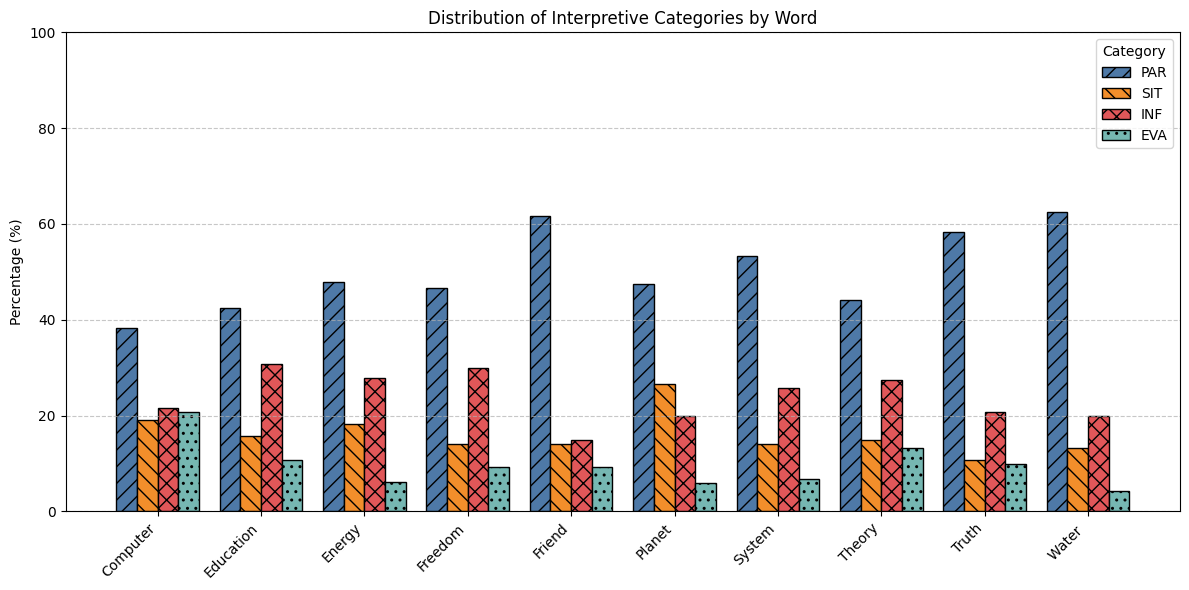

In [28]:
# Load the CSV file
df = pd.read_csv('/content/Final Overview_aggregate.csv')

# Convert to percent (data is already aggregated)
agg_percent = df.set_index('Word')[["PAR", "SIT", "INF", "EVA"]].div(
    df.set_index('Word')[["PAR", "SIT", "INF", "EVA"]].sum(axis=1), axis=0
) * 100

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.2
x = range(len(agg_percent))

# Define categories, hatching, and colors
categories = ["PAR", "SIT", "INF", "EVA"]
hatches = ["//", "\\\\", "xx", ".."]
colors = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2"]  # Colorblind-friendly palette

# Plot each category
for i, (cat, hatch, color) in enumerate(zip(categories, hatches, colors)):
    ax.bar(
        [p + i * bar_width for p in x],
        agg_percent[cat],
        width=bar_width,
        label=cat,
        color=color,
        edgecolor="black",
        hatch=hatch
    )

# Labeling
ax.set_xticks([p + 1.5 * bar_width for p in x])
ax.set_xticklabels(agg_percent.index, rotation=45, ha="right")
ax.set_ylabel("Percentage (%)")
ax.set_title("Distribution of Interpretive Categories by Word")
ax.set_ylim(0, 100)
ax.legend(title="Category", loc="upper right")

ax.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()



Removing 'Computer' as an outlier

In [29]:
df = pd.read_csv('/content/Final Overview_aggregate.csv')

# Clean the Word column
df['Word'] = df['Word'].str.strip()

# Filter out "Computer"
df_no_computer = df[df['Word'] != 'Computer'].copy()


# Convert raw counts to percentages per word
categories = ['PAR', 'SIT', 'INF', 'EVA']
df_no_computer['Total'] = df_no_computer[categories].sum(axis=1)
df_percent_no_computer = df_no_computer.copy()
for cat in categories:
    df_percent_no_computer[cat] = df_percent_no_computer[cat] / df_percent_no_computer['Total'] * 100

# Scale percentages to common total for chi-square
standard_total = 120
scaled_counts_no_computer = (df_percent_no_computer[categories] / 100 * standard_total).round().astype(int)

# -------------------------------
# METHOD 1: Global Chi-square Test
# -------------------------------
print("METHOD 1: CHI-SQUARE TEST WITH EFFECT SIZE FOCUS")
print("-" * 60)

contingency_table = scaled_counts_no_computer.values

# Perform chi-square test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

# Calculate effect size (Cramér's V)
n_total = contingency_table.sum()
cramers_v = np.sqrt(chi2_stat / (n_total * (min(contingency_table.shape) - 1)))

print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")
print(f"Cramér's V (effect size): {cramers_v:.4f}")

# Effect size interpretation
if cramers_v < 0.1:
    effect_interpretation = "negligible (< 0.1)"
elif cramers_v < 0.3:
    effect_interpretation = "small (0.1-0.3)"
elif cramers_v < 0.5:
    effect_interpretation = "medium (0.3-0.5)"
else:
    effect_interpretation = "large (≥ 0.5)"

print(f"Effect size interpretation: {effect_interpretation}")
print(f"Variance explained: {cramers_v**2:.1%}")
print(f"\n" + "="*60)

# -------------------------------
# METHOD 2: Separate Tests per Category
# -------------------------------
print("METHOD 2: SEPARATE TESTS FOR EACH CATEGORY (WITHOUT 'COMPUTER')")
print("-" * 60)
print("Testing if each category shows significant variation across words")

category_results_no_computer = {}

for category in categories:
    observed = scaled_counts_no_computer[category].values
    expected_equal = np.full(len(observed), np.mean(observed))

    # Chi-square goodness of fit
    chi2_cat, p_cat = stats.chisquare(observed, expected_equal)

    # Effect size: coefficient of variation
    cv = np.std(observed) / np.mean(observed)

    category_results_no_computer[category] = {
        'chi2': chi2_cat,
        'p_value': p_cat,
        'coefficient_variation': cv,
        'mean': np.mean(observed),
        'std': np.std(observed),
        'range': np.max(observed) - np.min(observed)
    }

    print(f"\n{category}:")
    print(f"  Chi-square: {chi2_cat:.4f}, p-value: {p_cat:.4f}")
    print(f"  Coefficient of variation: {cv:.4f}")
    print(f"  Mean ± SD: {np.mean(observed):.1f} ± {np.std(observed):.1f}")
    print(f"  Range: {np.min(observed)} - {np.max(observed)}")

print(f"\n" + "="*60)


METHOD 1: CHI-SQUARE TEST WITH EFFECT SIZE FOCUS
------------------------------------------------------------
Chi-square statistic: 44.5858
P-value: 0.006518
Degrees of freedom: 24
Cramér's V (effect size): 0.1174
Effect size interpretation: small (0.1-0.3)
Variance explained: 1.4%

METHOD 2: SEPARATE TESTS FOR EACH CATEGORY (WITHOUT 'COMPUTER')
------------------------------------------------------------
Testing if each category shows significant variation across words

PAR:
  Chi-square: 10.8079, p-value: 0.2128
  Coefficient of variation: 0.1393
  Mean ± SD: 61.9 ± 8.6
  Range: 51 - 75

SIT:
  Chi-square: 12.4211, p-value: 0.1334
  Coefficient of variation: 0.2695
  Mean ± SD: 19.0 ± 5.1
  Range: 13 - 32

INF:
  Chi-square: 11.5862, p-value: 0.1706
  Coefficient of variation: 0.2107
  Mean ± SD: 29.0 ± 6.1
  Range: 18 - 37

EVA:
  Chi-square: 9.8000, p-value: 0.2793
  Coefficient of variation: 0.3300
  Mean ± SD: 10.0 ± 3.3
  Range: 5 - 16



## Interpretive Strategy per discourse per word

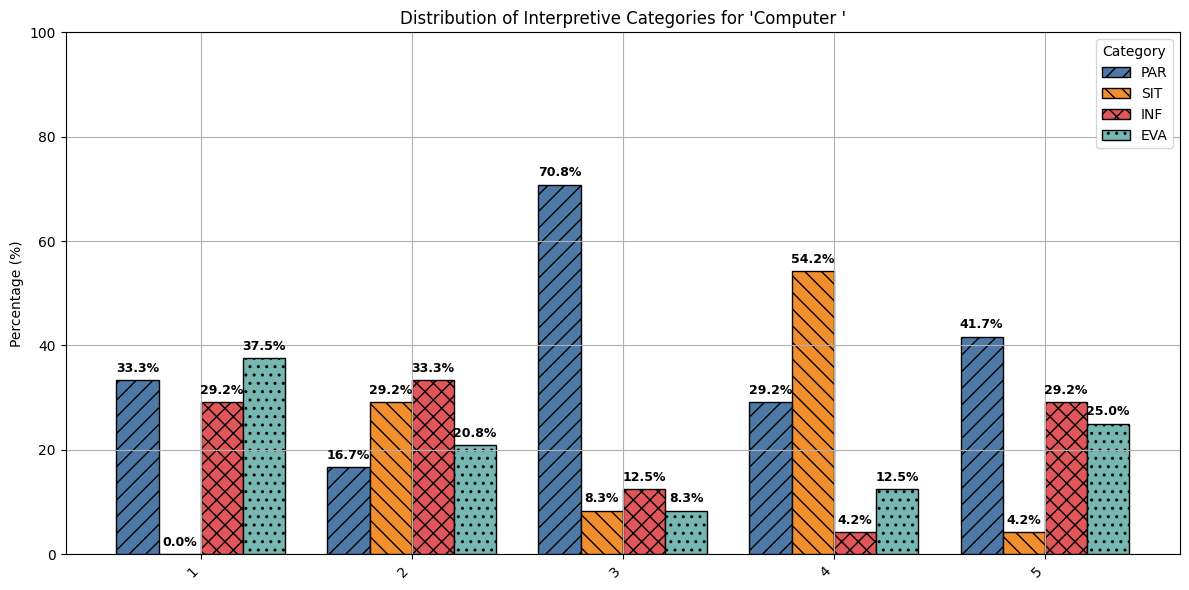

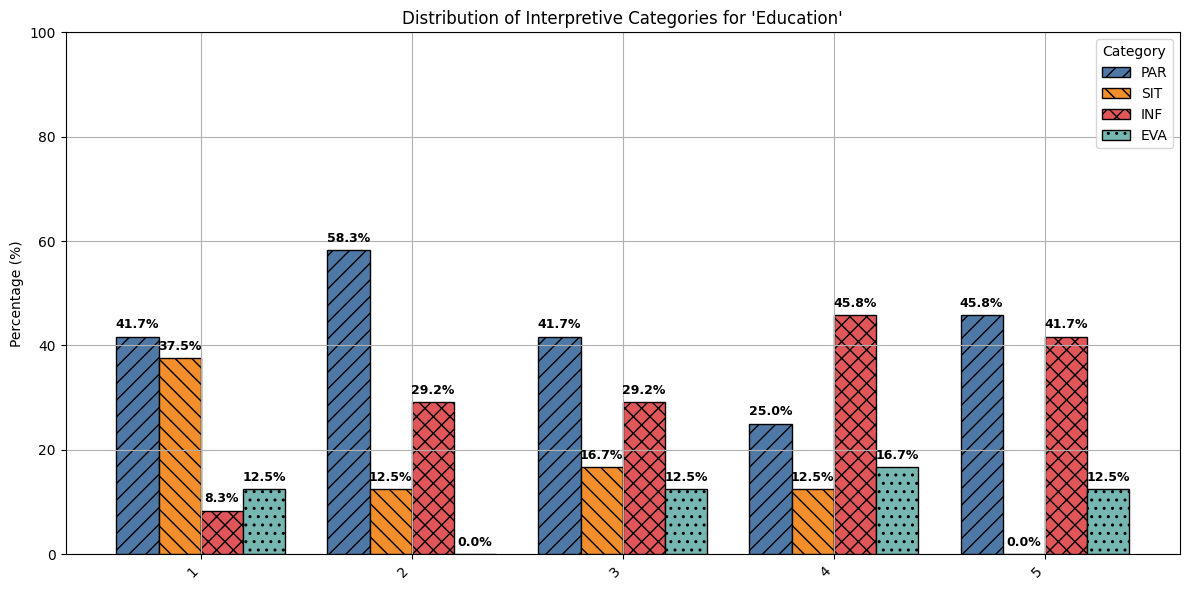

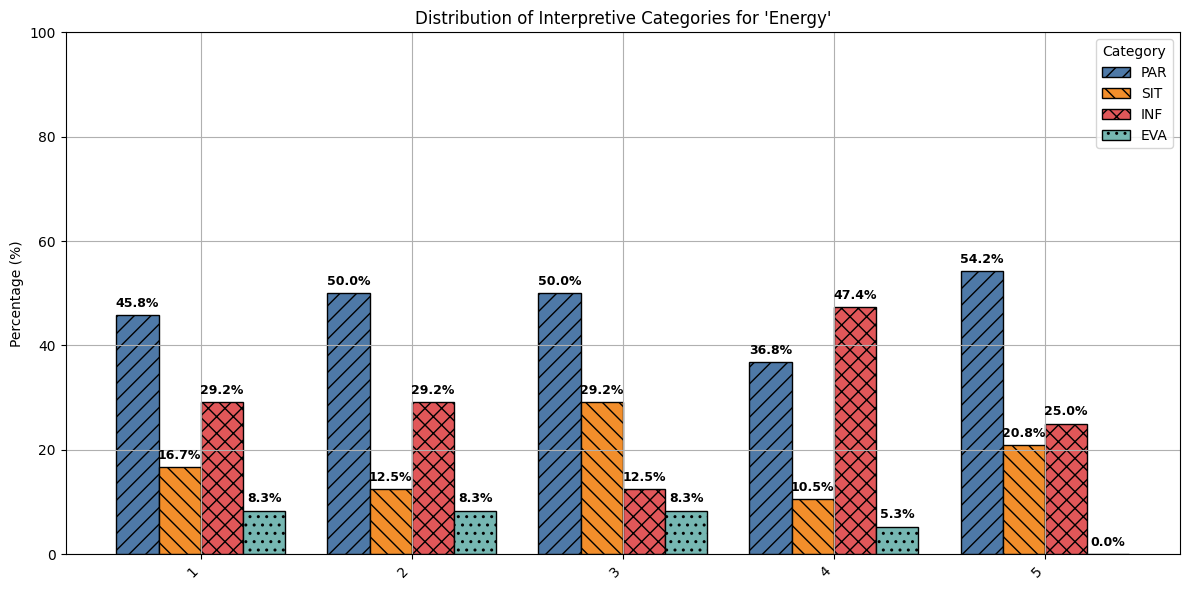

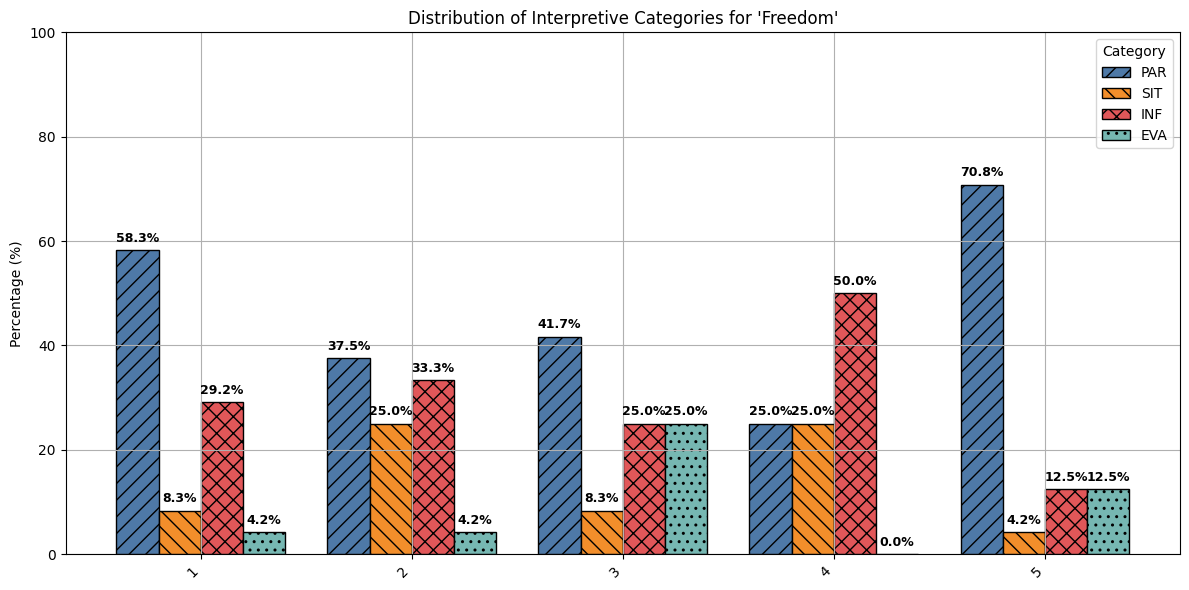

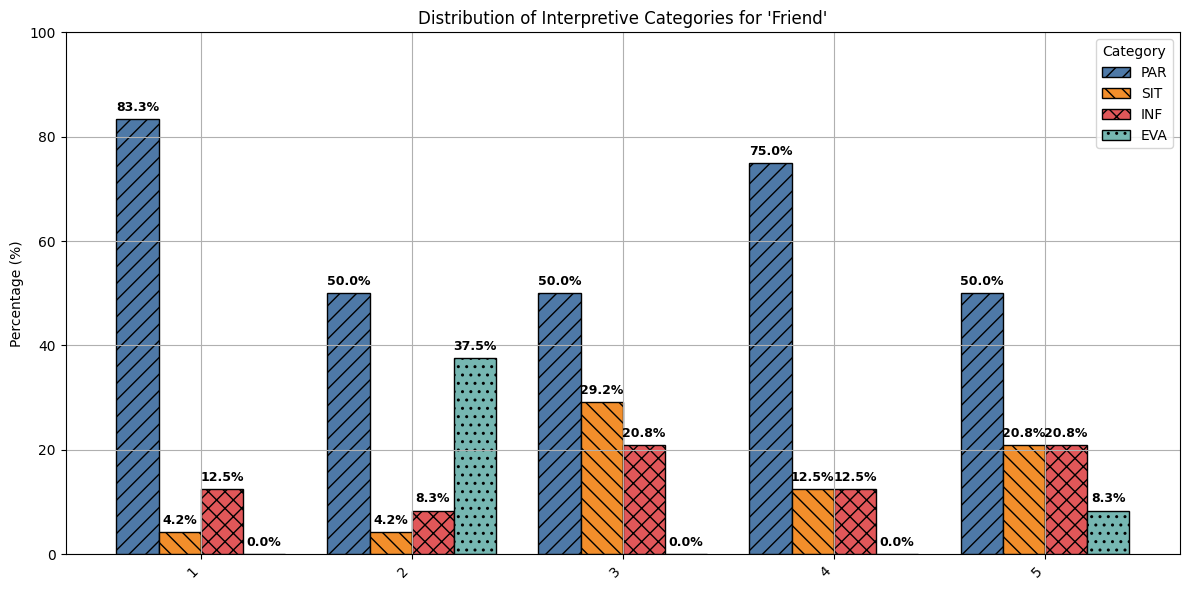

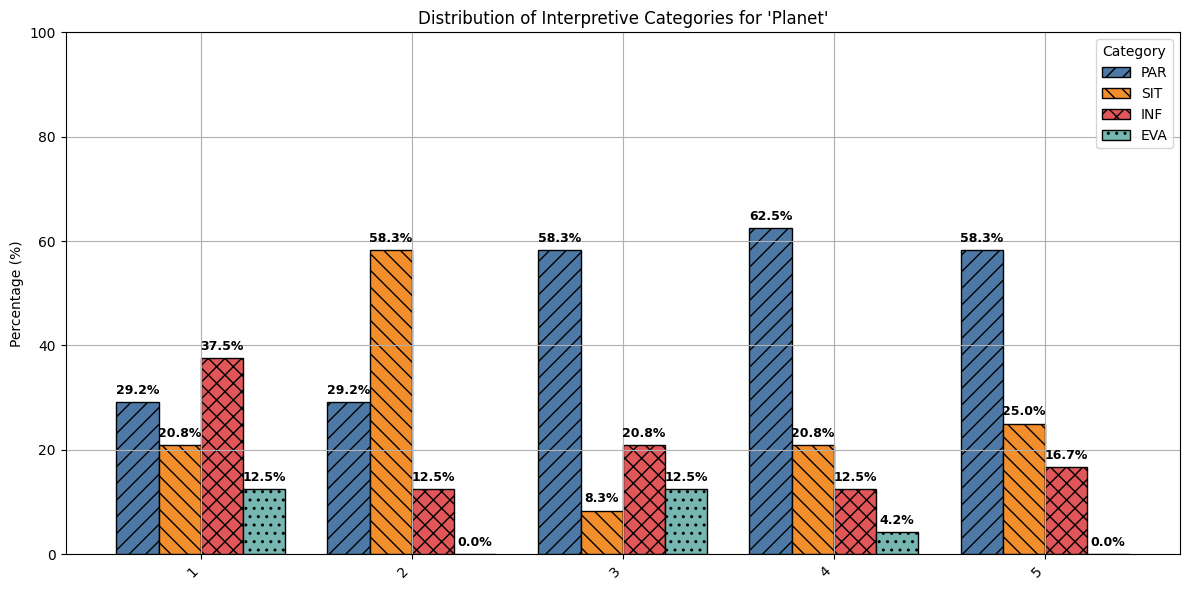

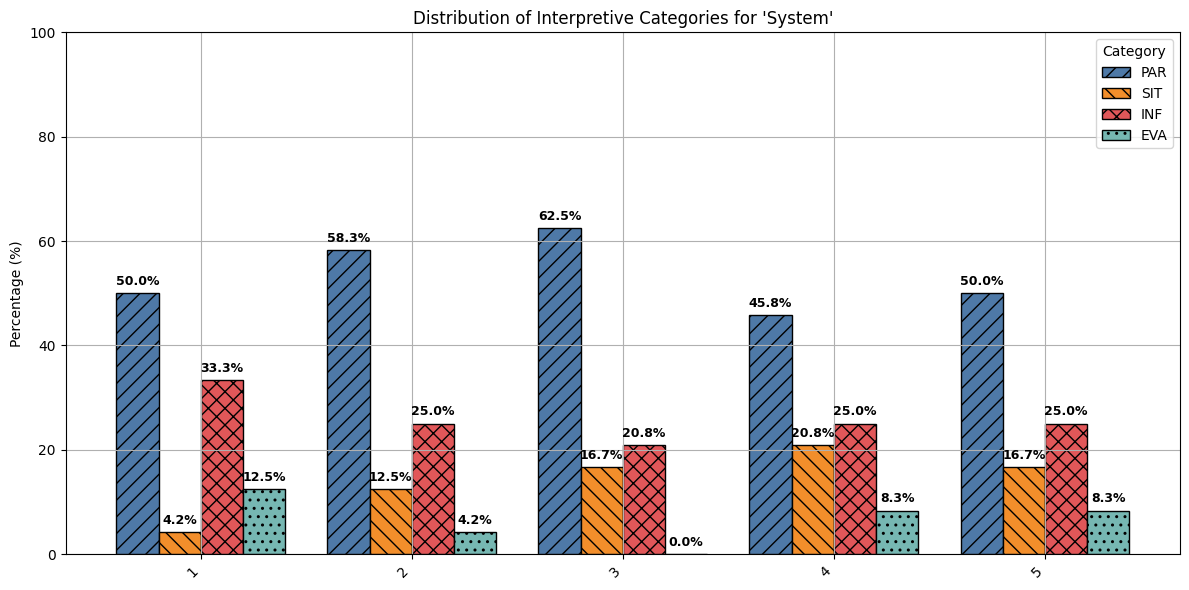

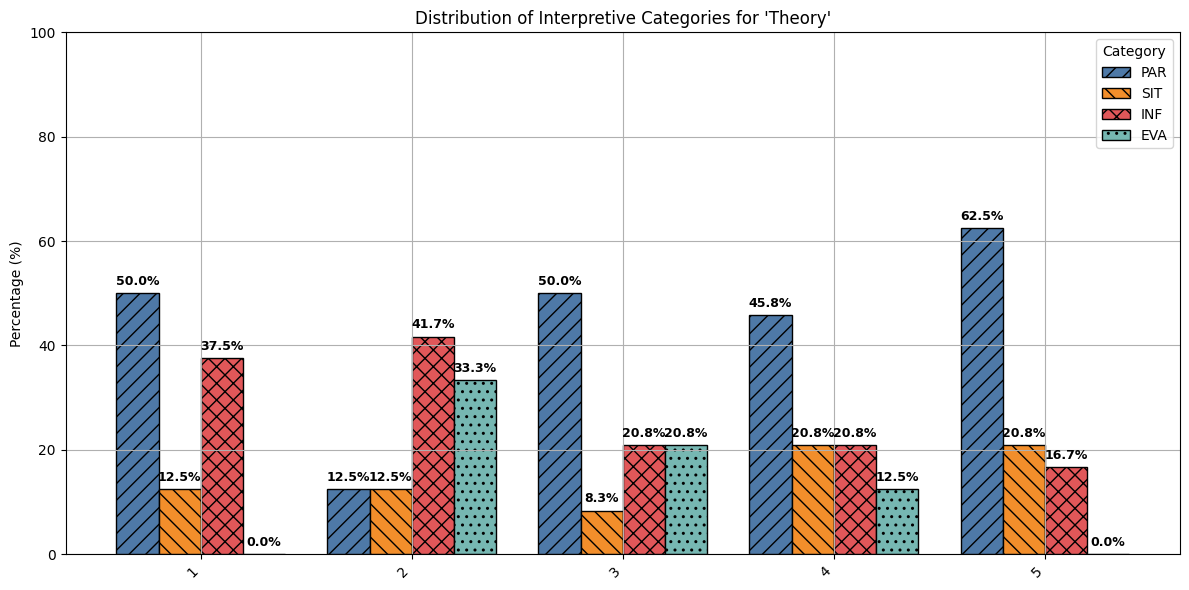

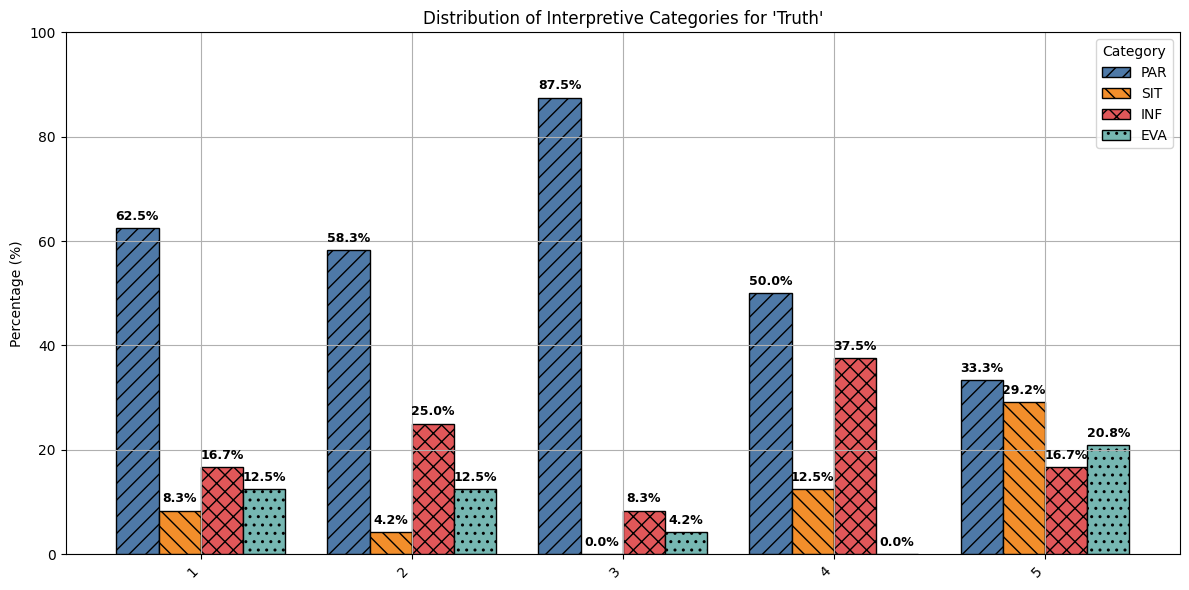

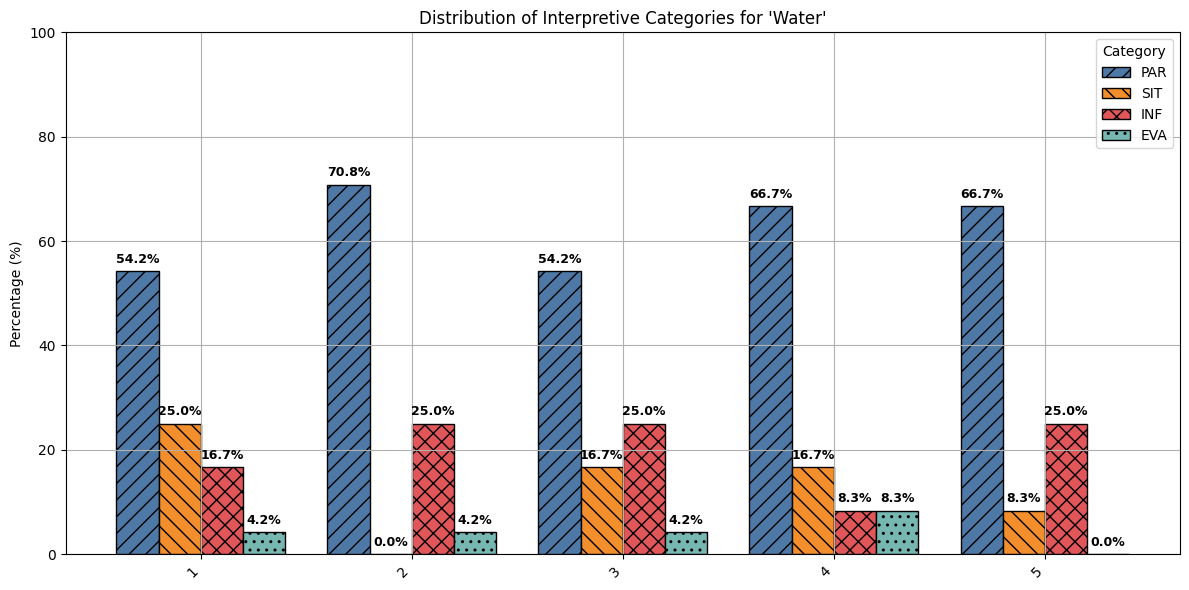

In [30]:
# Load the CSV file into a DataFrame
df = pd.read_csv('/content/Final Overview_individual.csv')

# Display the DataFrame
df.head(10)  # Displaying the first few rows of the DataFrame

# Convert to percentages by word and keep raw counts
agg = df.groupby(["Word", "Dialogue"])[["PAR", "SIT", "INF", "EVA"]].sum()
agg_percent = agg.div(agg.sum(axis=1), axis=0) * 100

# Define categories, hatching, and colors
categories = ["PAR", "SIT", "INF", "EVA"]
hatches = ["//", "\\\\", "xx", ".."]
colors = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2"]

# Plot for each word
for word in df["Word"].unique():
    # Filter data for the current word
    word_data_percent = agg_percent.xs(word, level="Word")
    word_data_counts = agg.xs(word, level="Word")

    # Plotting
    fig, ax = plt.subplots(figsize=(12, 6))
    bar_width = 0.2
    x = range(len(word_data_percent))

    # Plot each category
    for i, (cat, hatch, color) in enumerate(zip(categories, hatches, colors)):
        bars = ax.bar(
            [p + i * bar_width for p in x],
            word_data_percent[cat],
            width=bar_width,
            label=cat,
            color=color,
            edgecolor="black",
            hatch=hatch
        )

        # Add percentages above each bar
        for j, bar in enumerate(bars):
            height = bar.get_height()
            percentage = word_data_percent.iloc[j][cat]
            ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{percentage:.1f}%',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Labeling
    ax.set_xticks([p + 1.5 * bar_width for p in x])
    ax.set_xticklabels(word_data_percent.index, rotation=45, ha="right")
    ax.set_ylabel("Percentage (%)")
    ax.set_title(f"Distribution of Interpretive Categories for '{word}'")
    ax.set_ylim(0, 100)

    # Add some padding at the top for count labels
    ax.margins(y=0.1)
    ax.legend(title="Category", loc="upper right")

    # Display the grid
    ax.grid(True)

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()